<a href="https://colab.research.google.com/github/ackuyucu/Ekoloji_Lab/blob/main/Orneklem_yontemleri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

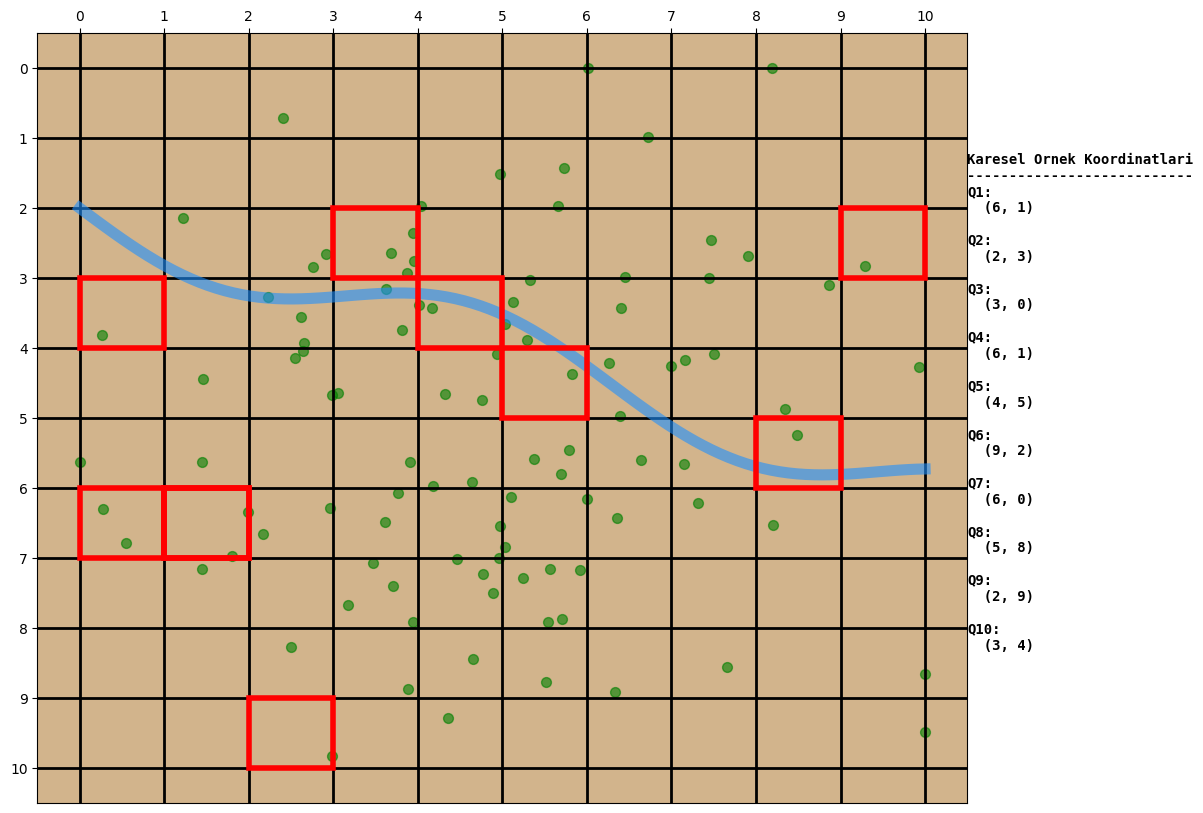

Bu calisma icin secilen agac dagilim tipi: Area B


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Kurulum ---
np.random.seed(12)
GRID_SIZE = 10

# --- Ornekleme Yontemi icin Kullanici Girisi ---
sampling_method = 'quadratic' # @param ['quadratic', 'transect', 'vertical_transect'] {type:'string'}

# --- Agac Dagilimi icin Kullanici Girisi ---
selected_area_type = 'Area B' # @param ['Area A', 'Area B'] {type:'string'}

tree_distribution_map = {
    'Area A': 'clumped',
    'Area B': 'gaussian'
}
tree_distribution_type = tree_distribution_map[selected_area_type]

# --- Ornekleme Mantigi ---
all_transects = []
list_str_title = ""

if sampling_method == 'transect':
    num_transects = 3
    transect_length = 5
    list_str_title = "Transect Koordinatlari\n-------------------\n"

    # 1. 3 baslangic numarasi sec
    starts = np.random.choice(range(1, 101), num_transects, replace=False)

    def get_coords(n):
        if n == 100: return 0, 0
        s = f"{n:02d}"
        return int(s[0]), int(s[1]) # Y, X dondurur

    # 2. Transektleri olustur
    for s in starts:
        y, x = get_coords(s)
        path = []
        curr_y, curr_x = y, x

        # Baslangic noktasini her zaman ekle
        path.append((curr_y, curr_x))

        for _ in range(transect_length - 1): # Kalan noktalari olustur
            curr_x = (curr_x + 1) % GRID_SIZE # X ekseninde sar
            if curr_x == 0: # Eger X sarildiysa, Y'yi artir ve gerekirse sar
                curr_y = (curr_y + 1) % GRID_SIZE
            path.append((curr_y, curr_x))
        all_transects.append({'start': s, 'path': path})

elif sampling_method == 'quadratic':
    num_quadratic_samples = 10
    list_str_title = "Karesel Ornek Koordinatlari\n---------------------------\n"

    # Tek kareler icin 10 rastgele koordinat olustur
    for i in range(num_quadratic_samples):
        y = np.random.randint(0, GRID_SIZE)
        x = np.random.randint(0, GRID_SIZE)
        # Her karesel ornek 1 uzunlugunda bir 'transect'tir
        all_transects.append({'start': f'Q{i+1}', 'path': [(y, x)]})

elif sampling_method == 'vertical_transect':
    num_transects = 3
    transect_length = 5
    list_str_title = "Dikey Transect Koordinatlari\n---------------------------\n"

    # 1. 3 baslangic numarasi sec
    starts = np.random.choice(range(1, 101), num_transects, replace=False)

    def get_coords(n):
        if n == 100: return 0, 0
        s = f"{n:02d}"
        return int(s[0]), int(s[1]) # Y, X dondurur

    # 2. Tam transect yollarini olustur
    for s in starts:
        y = get_coords(s)[0]
        x = get_coords(s)[1]
        path = []
        curr_y, curr_x = y, x

        # Baslangic noktasini her zaman ekle
        path.append((curr_y, curr_x))

        for _ in range(transect_length - 1): # Kalan noktalari olustur
            curr_y = (curr_y + 1) % GRID_SIZE # Y ekseninde sar
            if curr_y == 0: # Eger Y sarildiysa, X'i artir ve gerekirse sar
                curr_x = (curr_x + 1) % GRID_SIZE
            path.append((curr_y, curr_x))
        all_transects.append({'start': s, 'path': path})


# --- Gorsellestirme ---
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('#D2B48C')

# Izgara ve Etiketler
ax.set_xticks(np.arange(GRID_SIZE + 1))
ax.set_yticks(np.arange(GRID_SIZE + 1))
ax.grid(color='black', linewidth=2)
ax.set_xticklabels(range(GRID_SIZE + 1)); ax.set_yticklabels(range(GRID_SIZE + 1))
ax.invert_yaxis() # 0'in ustte oldugundan emin olun
ax.xaxis.tick_top() # X etiketlerini kusbakisi stiline gore uste tasi

# Nehir Ciz (Simule Edilmis)
rx = np.linspace(0, 10, 100)
ry = 2 + 0.5 * np.sin(rx) + 0.4 * rx
ax.plot(rx, ry, color='#1E90FF', linewidth=8, alpha=0.6)

# Agaclari Ciz (rastgele dagilmis yesil noktalar)
num_trees = 100 # Agac sayisini ayarlayabilirsiniz

tree_x = np.array([])
tree_y = np.array([])

if tree_distribution_type == 'clumped':
    # Alan A: Kume dagilimi
    num_clumps = np.random.randint(1, 6) # Rastgele kume sayisi (1 ila 5)
    trees_per_clump = num_trees // num_clumps

    # Kume merkezlerini kesin kenarlardan uzak tutmak icin bir tampon tanimlayin
    # Bu tampon, kume merkezi etrafinda agaclari olusturmak icin kullanilan standart sapma ile ilgilidir
    std_dev_for_clumps = 1.0
    buffer = 3.5 * std_dev_for_clumps # Kume merkezlerini kenarlardan daha uzakta tutmak icin tampon artirildi

    # Tamponun GRID_SIZE'in yarisini asmadigindan emin olun
    buffer = min(buffer, GRID_SIZE / 2 - 0.5) # Unifor icin kesinlikle pozitif gecerli bir aralik saglayin

    for _ in range(num_clumps):
        # Tampon bolgesi icinde kume merkezlerini secin
        clump_center_x = np.random.uniform(buffer, GRID_SIZE - buffer)
        clump_center_y = np.random.uniform(buffer, GRID_SIZE - buffer)

        # Kucuk bir standart sapma ile kume merkezi etrafinda noktalar olustur
        clump_x = np.random.normal(loc=clump_center_x, scale=std_dev_for_clumps, size=trees_per_clump)
        clump_y = np.random.normal(loc=clump_center_y, scale=std_dev_for_clumps, size=trees_per_clump)

        # Agaclarin izgara sinirlari icinde kalmasini saglayin (uc noktalar icin kesme hala gereklidir)
        clump_x = np.clip(clump_x, 0, GRID_SIZE)
        clump_y = np.clip(clump_y, 0, GRID_SIZE)

        tree_x = np.append(tree_x, clump_x)
        tree_y = np.append(tree_y, clump_y)

    # Eger num_trees tam bolunmuyorsa, kalan agaclari rastgele ekle
    remaining_trees = num_trees - len(tree_x)
    if remaining_trees > 0:
        tree_x = np.append(tree_x, np.random.uniform(0, GRID_SIZE, remaining_trees))
        tree_y = np.append(tree_y, np.random.uniform(0, GRID_SIZE, remaining_trees))

elif tree_distribution_type == 'gaussian':
    # Alan B: Gauss dagilimi
    gaussian_center_x = np.random.uniform(0, GRID_SIZE)
    gaussian_center_y = np.random.uniform(0, GRID_SIZE)
    gaussian_std_dev = np.random.uniform(1.5, 3.0) # Orta yayilma

    tree_x = np.random.normal(loc=gaussian_center_x, scale=gaussian_std_dev, size=num_trees)
    tree_y = np.random.normal(loc=gaussian_center_y, scale=gaussian_std_dev, size=num_trees)

    # Agaclarin izgara sinirlari icinde kalmasini saglayin
    tree_x = np.clip(tree_x, 0, GRID_SIZE)
    tree_y = np.clip(tree_y, 0, GRID_SIZE)


ax.scatter(tree_x, tree_y, color='green', marker='o', s=50, alpha=0.6, label='Trees')

# Ornekleri Ciz (Karesel veya Transect)
prominent_linewidth = 4 # Belirginlik artirildi
outline_color = 'red' # Basit kirmiziya degistirildi

list_str = list_str_title

for i, t in enumerate(all_transects):
    # Karesel ornekleme icin, 'start' 'Q1', 'Q2' vb. gibi olacaktir.
    # Transect ornekleme icin, baslangic numarasi olacaktir.
    list_str += f"{t['start']}:\n"
    for (y, x) in t['path']:
        # Ornegin her bir hucre si icin renkli bir dis cizgi cizin, ustte olmasini saglamak icin zorder ile
        rect = patches.Rectangle((x, y), 1, 1, linewidth=prominent_linewidth, edgecolor=outline_color, facecolor='none', zorder=10)
        ax.add_patch(rect)
        list_str += f"  ({y}, {x})\n"
    list_str += "\n"

plt.text(10.5, 5, list_str, family='monospace', va='center', fontweight='bold')
plt.show()

print(f"Bu calisma icin secilen agac dagilim tipi: {selected_area_type}")

### Poisson Uygunluk Testi (Spatial Randomness icin)

Bu bolum, alani bir quadratlar izgarasina boler, her bir quadrat icindeki agac sayisini sayar ve gozlenen sayim dagilimini teorik bir Poisson dagilimiyla karsilastirir.
* Bir **Poisson dagilimi**, tam uzaysal rastgeleligi modeller.
* Gozlenen dagilim Poisson'dan onemli olcude farklilik gosterirse (ornegin, ortalamadan daha yuksek varyans), bu kumeleme veya duzenli bir dagilimi gosterir.

--- Poisson Uygunluk Testi Sonuclari --- 

Toplam Quadratlar: 100
Toplam Agaclar: 100
Quadrat basi agac ortalamasi: 1.000
Quadrat basi agaclarin varyansi: 1.320
Varyans-Ortalama Orani (VMR): 1.320

VMR > 1: Bu, KUMELESMIS bir dagilimi gosterir.

Ki-Kare Istatistik: 7.250
P-degeri: 0.2027

Sonuc: Sifir hipotezini reddedemeyiz (p >= 0.05). Dagilim rastgeleden onemli olcude farklilik gostermez.


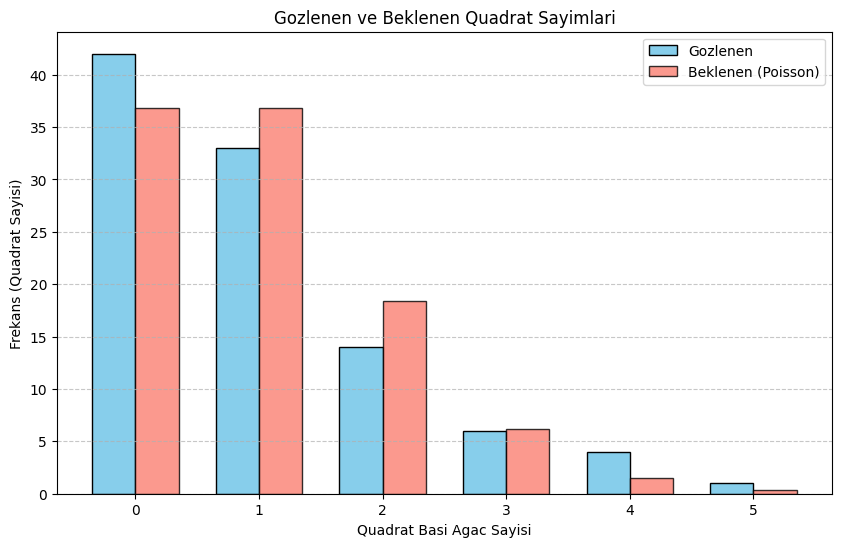

In [5]:
import numpy as np
from scipy.stats import chisquare, poisson
import pandas as pd
import matplotlib.pyplot as plt

# 1. Quadrat Sayimi
# Mevcut GRID_SIZE'i kullanacagiz, alani 1x1 quadratlara bolerek.
num_quadrats = GRID_SIZE * GRID_SIZE

# Her bir quadrat icindeki agac sayisini saymak icin 2D histogram olustur
counts, xedges, yedges = np.histogram2d(tree_x, tree_y, bins=GRID_SIZE, range=[[0, GRID_SIZE], [0, GRID_SIZE]])

# Sayimlari 1D diziye duzlestir (quadrat basi sayimlari temsil eder)
quadrat_counts = counts.flatten()

# 2. Gozlenen Frekanslari Hesapla
# Kac quadratin 0 agaci, 1 agaci, 2 agaci vb. oldugunu sayin.
max_count = int(np.max(quadrat_counts))
observed_freq = np.bincount(quadrat_counts.astype(int))

# Dizinin max_count'a kadar gittiginden emin olun (bazi ara sayimlarin 0 olmasi durumunda)
if len(observed_freq) <= max_count:
    observed_freq = np.pad(observed_freq, (0, max_count - len(observed_freq) + 1), 'constant')

# 3. Beklenen Frekanslari Hesapla (Poisson)
mean_trees_per_quadrat = np.mean(quadrat_counts)

expected_prob = poisson.pmf(np.arange(max_count + 1), mean_trees_per_quadrat)
# Toplami 1'e ulasmak icin kalan tum olasilik kutlesini icerecek sekilde son olasiligi ayarlayin
expected_prob[-1] += 1 - np.sum(expected_prob)
expected_freq = expected_prob * num_quadrats

# 4. Ki-Kare Uygunluk Testi
# Ki-Kare varsayimlarini karsilamak icin cok dusuk beklenen frekanslara (< 5) sahip kategorileri birlestirin
# Basitlik acisindan burada dogrudan calistiracagiz, ancak beklenen sayimlarin dusuk olmasi durumunda uyarinin farkinda olun
try:
    chi2_stat, p_value = chisquare(f_obs=observed_freq, f_exp=expected_freq)
except ValueError as e:
    print(f"Uyari: {e}. Bu genellikle beklenen frekanslarin 0 olmasi durumunda meydana gelir. Kutulari birlestirmeyi dusunun.")
    chi2_stat, p_value = np.nan, np.nan

# 5. Varyans-Ortalama Oranini Hesapla (VMR)
# VMR ~ 1: Rastgele (Poisson)
# VMR > 1: Kumelenmis
# VMR < 1: Duzgun/Duzenli
variance_trees_per_quadrat = np.var(quadrat_counts)
vmr = variance_trees_per_quadrat / mean_trees_per_quadrat

# --- Sonuclari Goster ---
print(f"--- Poisson Uygunluk Testi Sonuclari --- \n")
print(f"Toplam Quadratlar: {num_quadrats}")
print(f"Toplam Agaclar: {len(tree_x)}")
print(f"Quadrat basi agac ortalamasi: {mean_trees_per_quadrat:.3f}")
print(f"Quadrat basi agaclarin varyansi: {variance_trees_per_quadrat:.3f}")
print(f"Varyans-Ortalama Orani (VMR): {vmr:.3f}")

if vmr > 1.1:
    print("\nVMR > 1: Bu, KUMELESMIS bir dagilimi gosterir.")
elif vmr < 0.9:
    print("\nVMR < 1: Bu, DUZENLI (uniform) bir dagilimi gosterir.")
else:
    print("\nVMR ~ 1: Bu, RASTGELE (Poisson) bir dagilimi gosterir.")

print(f"\nKi-Kare Istatistik: {chi2_stat:.3f}")
print(f"P-degeri: {p_value:.4f}")

alpha = 0.05
if not np.isnan(p_value):
    if p_value < alpha:
        print(f"\nSonuc: Sifir hipotezini reddet (p < {alpha}). Dagilim rastgeleden onemli olcude farklidir.")
    else:
        print(f"\nSonuc: Sifir hipotezini reddedemeyiz (p >= {alpha}). Dagilim rastgeleden onemli olcude farklilik gostermez.")

# --- Gorsellestirme ---
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(observed_freq))
width = 0.35

ax.bar(x_pos - width/2, observed_freq, width, label='Gozlenen', color='skyblue', edgecolor='black')
ax.bar(x_pos + width/2, expected_freq, width, label='Beklenen (Poisson)', color='salmon', edgecolor='black', alpha=0.8)

ax.set_xlabel('Quadrat Basi Agac Sayisi')
ax.set_ylabel('Frekans (Quadrat Sayisi)')
ax.set_title('Gozlenen ve Beklenen Quadrat Sayimlari')
ax.set_xticks(x_pos)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()